In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


c:\Users\Trainee\python stuff\pk_H2_an_01\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "syedbaqarx/iea-hydrogen-production-projects-database" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

100%|██████████| 263k/263k [00:00<00:00, 869kB/s]

Extracting files...
Loading dataset from C:\Users\Trainee\.cache\kagglehub\datasets\syedbaqarx\iea-hydrogen-production-projects-database\versions\1 to ../data/raw\iea-hydrogen-production-projects-database
Moving file: C:\Users\Trainee\.cache\kagglehub\datasets\syedbaqarx\iea-hydrogen-production-projects-database\versions\1\projects.csv to c:\Users\Trainee\python stuff\pk_H2_an_01\notebooks\../data/raw\iea-hydrogen-production-projects-database
Moving file: C:\Users\Trainee\.cache\kagglehub\datasets\syedbaqarx\iea-hydrogen-production-projects-database\versions\1\references.csv to c:\Users\Trainee\python stuff\pk_H2_an_01\notebooks\../data/raw\iea-hydrogen-production-projects-database
Files moved to '../data/raw\iea-hydrogen-production-projects-database' directory.


In [3]:
files

['projects.csv', 'references.csv']

In [4]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,Unnamed: 0,Ref,Project name,Country,Date online,Decomission date,Status,Technology,Technology_details,Technology_electricity,...,Capacity_MWel,Capacity_Nm³ H₂/h,Capacity_kt H2/y,Capacity_t CO₂ captured/y,IEA zero-carbon estimated normalized capacity [Nm³ H₂/hour],References,Latitude,Longitude,Technology_aggregate,LOWE_CF
0,0,NaN,Other projects from confidential sources (post...,NaN,NaN,NaN,Other,NG w CCUS,NaN,NaN,...,NaN,3.535952e+06,2756.769803,NaN,0.000000e+00,NaN,NaN,NaN,Fossil fuels with CCUS,NaN
1,1,NaN,Other projects from confidential sources (post...,NaN,NaN,NaN,Other,Other,Various types,NaN,...,NaN,6.255649e+05,487.715413,NaN,0.000000e+00,NaN,NaN,NaN,Other,NaN
2,2,NaN,Other projects from confidential sources (post...,NaN,NaN,NaN,Other,Other Electrolysis,Various types,NaN,...,17443.883124,3.876418e+06,3022.210898,NaN,3.876418e+06,NaN,NaN,NaN,Electrolysis,NaN
3,3,NaN,Other projects from confidential sources (2000...,NaN,NaN,NaN,Operational,PEM,NaN,NaN,...,6.541400,1.257962e+03,0.980757,NaN,1.257962e+03,NaN,NaN,NaN,Electrolysis,NaN
4,4,NaN,Other projects from confidential sources (2000...,NaN,NaN,NaN,Operational,ALK,NaN,NaN,...,141.760154,3.081742e+04,24.026497,NaN,3.081742e+04,NaN,NaN,NaN,Electrolysis,NaN


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(2441, 37)

'Description'

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,2441.0,1220.00,704.80,0.00,610.00,1220.00,1830.00,2440.00
Ref,2434.0,1745.65,876.59,3.00,1013.50,1822.50,2485.75,3160.00
Date online,1879.0,2024.08,6.27,1965.00,2023.00,2025.00,2027.00,2043.00
Decomission date,114.0,2016.28,6.89,2004.00,2013.00,2016.00,2019.00,2063.00
EndUse_Refining,154.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
EndUse_Ammonia,422.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
EndUse_Methanol,168.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
EndUse_Iron&Steel,108.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
EndUse_Other Ind,427.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
EndUse_Mobility,696.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
Unnamed: 0,int64,0,2441,"[703, 2187, 295]"
Ref,float64,7,2433,"[2164.0, 1807.0, 3132.0]"
Project name,object,0,2413,"[H2Perth NG with CCUS - I, Hynoca Alkmaar, H2C..."
Country,object,7,102,"[OMN, JPN, MYS]"
Date online,float64,562,45,"[2024.0, 2035.0, 2035.0]"
Decomission date,float64,2327,24,"[nan, nan, nan]"
Status,object,9,8,"[Concept, Feasibility study, Concept]"
Technology,object,1,13,"[Other Electrolysis, PEM, Other Electrolysis]"
Technology_details,object,816,47,"[nan, Unknown PtX, Unknown PtX]"
Technology_electricity,object,297,6,"[Dedicated renewable, Dedicated renewable, Ded..."


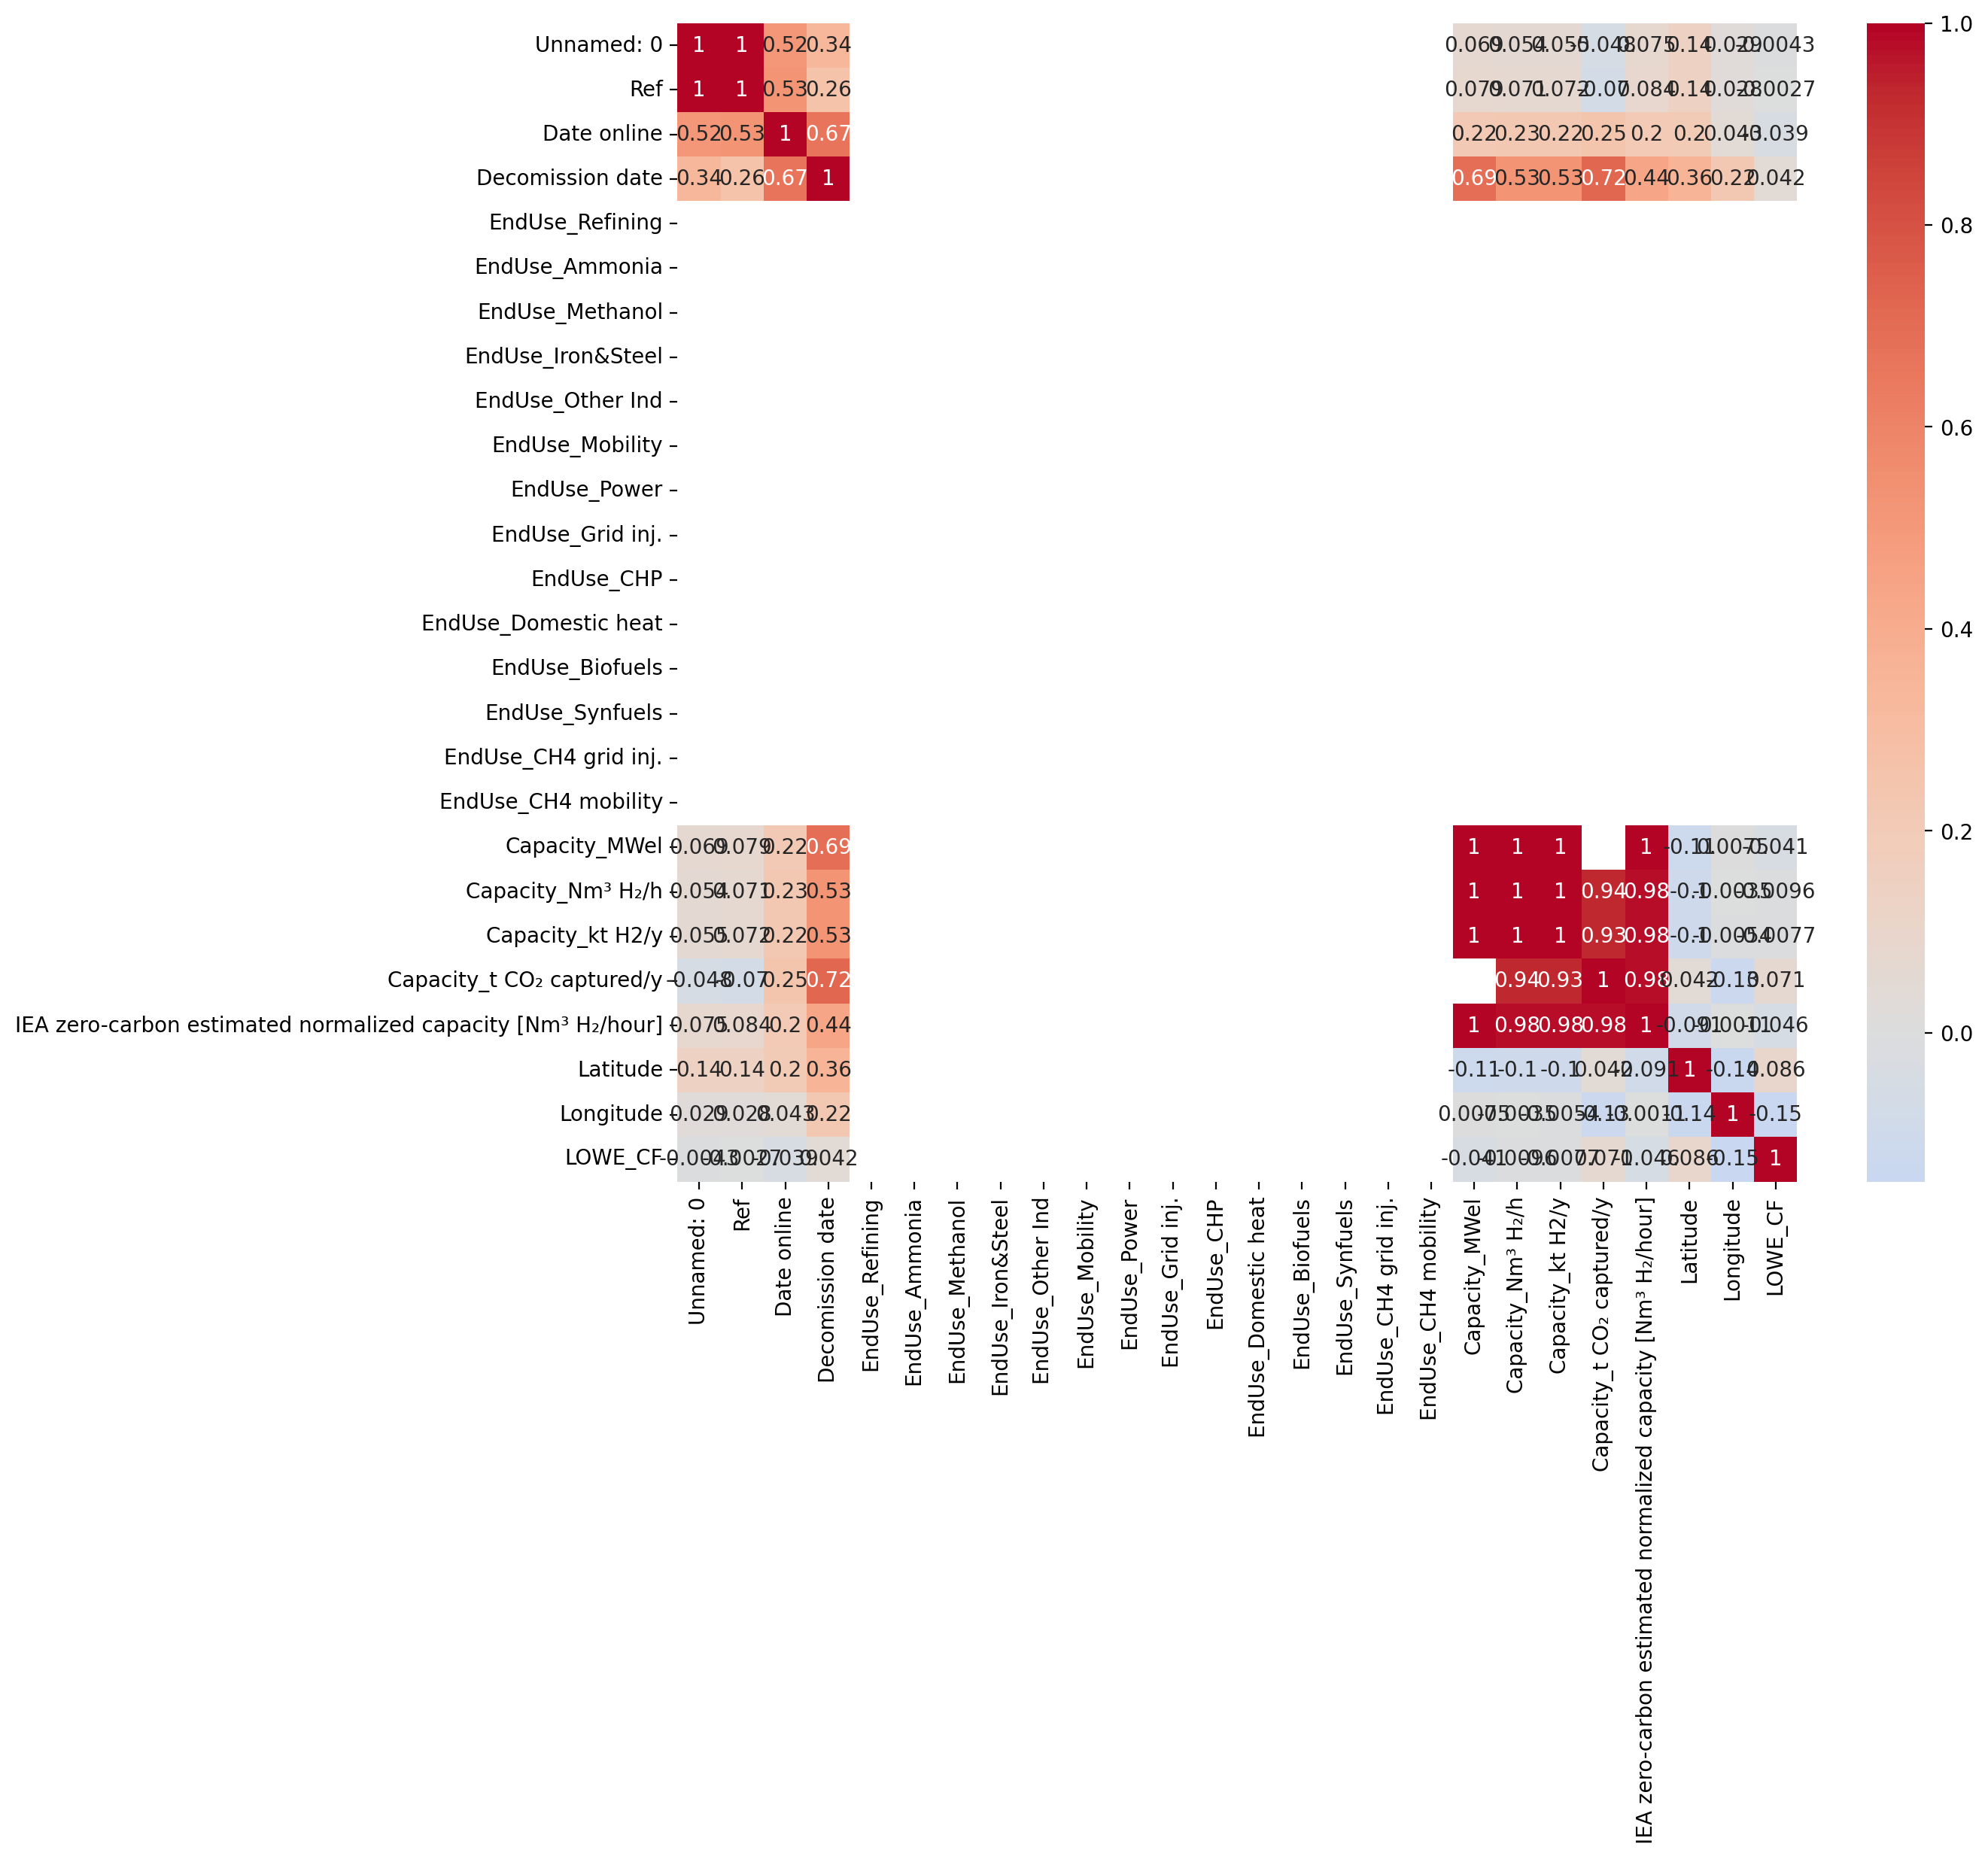

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);